Инерция модели: 31.371358974358976


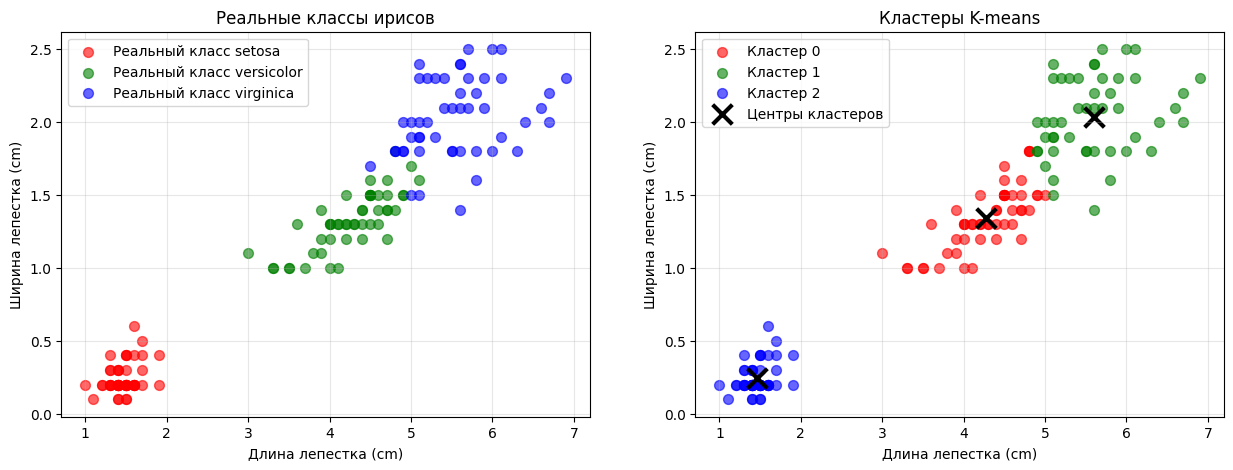

In [22]:
import numpy as np
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import pandas as pd
from typing import Optional, Tuple


class Kmeans:
    def __init__(self, k):
        self.k = k
        self.X = None
        self.centers = None
        self.labels = None

    def _InitCentres(self):
        self.centers =  self.X[np.random.choice(len(self.X), size=self.k, replace=False)]
    
    def _expectation(self):
        distances = np.array([np.sqrt(np.sum((self.X - center) ** 2, axis=1)) 
                                   for center in self.centers])
        self.labels = np.argmin(distances, axis=0)

    def _maximization(self):
        for i in range(self.k):
            mask = self.labels == i
            if mask.any():
                self.centers[i] = np.mean(self.X[mask], axis=0)
            else:
                self.centers[i] = self.X[np.random.choice(len(self.X))]

    #Норм, но можно оптимизировать
    def Quality(self):
        total = 0
        for i in range(self.k):
            mask = self.labels == i
            if mask.any(): 
                distance = np.sqrt(np.sum((self.X[mask] - self.centers[i]) ** 2, axis=1))
            total += np.sum(distance**2)
        return total
    
    #Добавить условия сходимости(убрать или модифицировать max_iter параметр)
    def fit(self, X, max_iter=100):
        self.X = X
        self._InitCentres()
        for i in range(max_iter):
            self._expectation()
            self._maximization()
        return self

#\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\ 
#Общие методы
def fit_best(X, k, init_num):
    lst = []
    for _ in range(init_num):
        model = Kmeans(k)
        model.fit(X)
        lst.append((model.Quality(), model))
    lst.sort(key=lambda x: x[0])
    best_quality, best_model = lst[0]
    return best_model, best_quality


#Здесь предполагается изменение масштаба данных(пока нету)
def prepare_data(X, y):
    pass

def fit_best(X, k, init_num=100):
    lst = []
    for _ in range(init_num):
        model = Kmeans(k)
        model.fit(X)
        lst.append((model.Quality(), model))
    lst.sort(key=lambda x: x[0])
    best_quality, best_model = lst[0]
    return best_model, best_quality

def plot_clusters(model, X_plot, y, quality):
    colors = ["red", "green", "blue", "yellow", "black"]
    y_pred = model.labels
    centers = model.centers
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    for i in range(3):
         ax1.scatter(X_plot.iloc[y==i, 0], 
                X_plot.iloc[y==i, 1],
                c=colors[i], 
                label=f'Реальный класс {iris.target_names[i]}',
                alpha=0.6, s=50)
         
    ax1.set_xlabel('Длина лепестка (cm)')
    ax1.set_ylabel('Ширина лепестка (cm)')
    ax1.set_title('Реальные классы ирисов')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    for i in range(model.k):
        ax2.scatter(X_plot.iloc[y_pred==i, 0], 
                X_plot.iloc[y_pred==i, 1],
                c=colors[i], 
                label=f'Кластер {i}',
                alpha=0.6, s=50)
        
    ax2.scatter(centers[:, 0], centers[:, 1], 
            marker='x', c='black', s=200, linewidths=3,
            label='Центры кластеров')
    ax2.set_xlabel('Длина лепестка (cm)')
    ax2.set_ylabel('Ширина лепестка (cm)')
    ax2.set_title('Кластеры K-means')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    print(f"Инерция модели: {quality}")

#////////////////////////////////////////////
#main часть

np.random.seed(10)
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

X_train = X[['petal length (cm)', 'petal width (cm)']].values.astype(np.float64)
X_plot = X[['petal length (cm)', 'petal width (cm)']]
prepare_data(X_train, y)
model, quality = fit_best(X_train, k=3, init_num=100)
plot_clusters(model, X_plot, y, quality)


In [6]:
def train_test_split(
    X: np.ndarray, 
    y: np.ndarray, 
    test_size: float = 0.25, 
    random_state: Optional[int] = 42, 
    shuffle: bool = True
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    # Разбивает данные на обучающую и тестовую выборки
    
    n_test = int(len(X) * test_size)
    indices = np.arange(len(X))
    
    if shuffle:
        np.random.seed(random_state)
        # shuffle изменяет массив на месте(перемешивает)
        np.random.shuffle(indices)
    
    # Индексы для train/test
    ind_train = indices[n_test:]
    ind_test = indices[:n_test]
    
    X_train = X[ind_train]
    X_test = X[ind_test]
    y_train = y[ind_train]
    y_test = y[ind_test]

    return X_train, X_test, y_train, y_test

In [10]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import pandas as pd

def prepare_data(X, y):
    pass

def fit_best(X, k, init_num=100):
    lst = []
    for _ in range(init_num):
        model = Kmeans(k)
        model.fit(X)
        lst.append((model.Quality(), model))
    lst.sort(key=lambda x: x[0])
    best_quality, best_model = lst[0]
    return best_model, best_quality

def plot_clusters(model, X_plot, y, quality):
    colors = ["red", "green", "blue"]
    y_pred = model.labels
    centers = model.centers
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    for i in range(3):
         ax1.scatter(X_plot.iloc[y==i, 0], 
                X_plot.iloc[y==i, 1],
                c=colors[i], 
                label=f'Реальный класс {iris.target_names[i]}',
                alpha=0.6, s=50)
         
    ax1.set_xlabel('Длина лепестка (cm)')
    ax1.set_ylabel('Ширина лепестка (cm)')
    ax1.set_title('Реальные классы ирисов')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    for i in range(3):
        ax2.scatter(X_plot.iloc[y_pred==i, 0], 
                X_plot.iloc[y_pred==i, 1],
                c=colors[i], 
                label=f'Кластер {i}',
                alpha=0.6, s=50)
        
    ax2.scatter(centers[:, 0], centers[:, 1], 
            marker='x', c='black', s=200, linewidths=3,
            label='Центры кластеров')
    ax2.set_xlabel('Длина лепестка (cm)')
    ax2.set_ylabel('Ширина лепестка (cm)')
    ax2.set_title('Кластеры K-means')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    print(f"Инерция модели: {quality}")

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target
X_train = X[['petal length (cm)', 'petal width (cm)']].values.astype(np.float64)
prepare_data(X_train, y)
model, quality = fit_best(X_train, k=3, init_num=100)
plot_clusters(model, X_train, y)


TypeError: EuclideanMetric.compute_batch() missing 1 required positional argument: 'X'